# NB01 — Curator-Like Priority Queue

**Project**: `fitness_browser_stubborn_set`

**Goal**: Rank every non-reannotated Fitness Browser gene by how *curator-like*
its primary evidence profile looks (i.e., how closely it resembles the genes in
`kescience_fitnessbrowser.reannotation`). The output is a single ranked list
that NB02 will walk top-down in chunks of 1,000, applying secondary evidence
until the yield of improvable candidates flattens.

**Why a queue, not a threshold?** Earlier exploration showed the dual target of
≥90% recall AND <10K stubborn cannot be hit from primary fitness/cofitness
features alone — too many non-reannotated genes have evidence profiles
indistinguishable from reannotated ones. Rather than pick a binding threshold
and hide the data behind it, we expose the rank order and let NB02/NB03 stop
walking when secondary evidence stops yielding improvable candidates.

**Inputs**: local parquet from `00_extract_gene_features.py`.
**Outputs**: `data/priority_queue.parquet`, `data/chunk_summary.csv`, figures.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name and not (REPO_ROOT / ".venv-berdl").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
PROJECT_DIR = REPO_ROOT / "projects" / "fitness_browser_stubborn_set"
DATA_DIR = PROJECT_DIR / "data"
FIG_DIR = PROJECT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = DATA_DIR / "gene_evidence_features.parquet"
assert FEATURES_PATH.exists(), "Run notebooks/00_extract_gene_features.py first"

CHUNK_SIZE = 1000

## 1. Load + restrict to curated organisms

The 12 organisms with zero reannotations are dropped — they may be uncurated
rather than "left alone after review", and including them inflates the
baseline.

In [2]:
df_all = pd.read_parquet(FEATURES_PATH)
print(f"Loaded {len(df_all):,} FB genes (all 48 orgs)")

curated_orgs = sorted(df_all.loc[df_all.is_reannotated == 1, "orgId"].unique())
df = df_all[df_all["orgId"].isin(curated_orgs)].copy()
n_dropped = len(df_all) - len(df)
n_reann = int(df.is_reannotated.sum())
n_other = int(len(df) - n_reann)
print(f"After restriction: {len(df):,} genes from {len(curated_orgs)} curated organisms")
print(f"  reannotated: {n_reann:,}")
print(f"  other:       {n_other:,}")
print(f"  dropped:     {n_dropped:,} from {48 - len(curated_orgs)} uncurated orgs")

Loaded 182,447 FB genes (all 48 orgs)
After restriction: 139,527 genes from 35 curated organisms
  reannotated: 1,729
  other:       137,798
  dropped:     42,920 from 13 uncurated orgs


## 2. Evidence features

Six per-gene features, all from primary fitness + cofitness data:

| Feature | Definition |
|---|---|
| `in_specificphenotype` | binary 0/1 — Price's precomputed specific-phenotype flag |
| `max_abs_fit` | largest \|fit\| across experiments (clipped to [0, 8]) |
| `max_abs_t` | largest \|t\| across experiments (clipped to [0, 20]) |
| `log_n_strong` | log1p of # experiments with \|fit\|≥2 AND \|t\|≥5 |
| `log_n_moderate` | log1p of # experiments with \|fit\|≥1 AND \|t\|≥5 |
| `max_cofit` | largest cofit with any partner in same organism |

In [3]:
X = pd.DataFrame({
    "in_specificphenotype": df.in_specificphenotype.astype(float),
    "max_abs_fit":           np.clip(df.max_abs_fit, 0, 8),
    "max_abs_t":             np.clip(df.max_abs_t, 0, 20),
    "log_n_strong":          np.log1p(df.n_strong_experiments),
    "log_n_moderate":        np.log1p(df.n_moderate_experiments),
    "max_cofit":             df.max_cofit.astype(float),
})
y = df.is_reannotated.astype(int).values

scaler = StandardScaler()
Xs = scaler.fit_transform(X.values)

logit = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=0)
logit.fit(Xs, y)
df["score"] = logit.predict_proba(Xs)[:, 1]

print("Logistic regression weights (standardised features):")
weights = pd.Series(logit.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print(weights.round(3).to_string())
print(f"Intercept: {logit.intercept_[0]:.3f}")
print(f"\nScore range: [{df.score.min():.4f}, {df.score.max():.4f}]")

# Counting flags too — useful as ground-truth-like reference
df["C1_specific"] = df.in_specificphenotype.astype(int)
df["C2_strong"]   = (df.n_strong_experiments >= 1).astype(int)
df["C3_cofit"]    = (df.max_cofit >= 0.75).astype(int)
df["count_score"] = df.C1_specific + df.C2_strong + df.C3_cofit

Logistic regression weights (standardised features):
in_specificphenotype    0.978
max_abs_fit             0.887
max_cofit               0.683
log_n_strong            0.224
log_n_moderate         -0.210
max_abs_t              -0.080
Intercept: -2.282

Score range: [0.0110, 0.9981]


## 3. Annotation category (descriptive)

Categorise existing `gene.desc` into {`hypothetical`, `DUF`, `vague`,
`named_enzyme`, `named_other`}. **Descriptive only — not used in scoring or
ranking.** Used downstream to characterise *what kind* of genes appear at each
rank position.

In [4]:
def categorise_desc(desc: str) -> str:
    d = (desc or "").strip().lower()
    if not d or d.startswith("locus ") or d in {"-", ""}:
        return "hypothetical"
    if "hypothetical" in d or "uncharacterized" in d or "unknown function" in d:
        if "duf" in d or "upf" in d:
            return "DUF"
        return "hypothetical"
    if "duf" in d or "upf" in d:
        return "DUF"
    if any(tok in d for tok in ("putative", "predicted", "probable", "possible")):
        return "vague"
    enz_tokens = ("ase ", "ase,", "ase/", "ase-", "ligase", "reductase", "transporter",
                  "kinase", "synthase", "dehydrogenase", "permease", "oxidase", "transferase",
                  "hydrolase", "isomerase", "mutase", "polymerase")
    if any(tok in d for tok in enz_tokens) or d.endswith("ase"):
        return "named_enzyme"
    return "named_other"


df["annotation_category"] = df["gene_desc"].astype(str).map(categorise_desc)

## 4. Build the priority queue

Sort all non-reannotated genes by `score` (descending). Assign rank and chunk.

In [5]:
queue = (
    df[df.is_reannotated == 0]
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)
queue["rank"] = np.arange(1, len(queue) + 1)
queue["chunk"] = ((queue["rank"] - 1) // CHUNK_SIZE) + 1
print(f"Priority queue: {len(queue):,} non-reannotated genes")
print(f"Chunks of {CHUNK_SIZE:,}: {int(queue['chunk'].max())}")
print(queue[["rank", "score", "C1_specific", "C2_strong", "C3_cofit",
             "annotation_category", "gene_desc"]].head(10).to_string(index=False))

Priority queue: 137,798 non-reannotated genes
Chunks of 1,000: 138
 rank    score  C1_specific  C2_strong  C3_cofit annotation_category                                                                      gene_desc
    1 0.998131            1          1         1        named_enzyme                                         3-oxoadipate CoA-transferase subunit A
    2 0.998013            1          1         1        named_enzyme                                         3-oxoadipate CoA-transferase subunit A
    3 0.997937            1          1         1        named_enzyme                                     protocatechuate 3,4-dioxygenase beta chain
    4 0.997737            1          1         1         named_other two component, sigma54 specific, Fis family transcriptional regulator (RefSeq)
    5 0.997732            1          1         1        named_enzyme                                                   beta-ketoadipyl-CoA thiolase
    6 0.997492            1          1       

## 5. Cumulative reannotation hits vs rank

For each rank R, what fraction of all reannotated genes have a higher score
than the rank-R gene in the queue? This curve answers the question "when does
the curator-like signal in the priority queue trail off?"

In [6]:
# All genes ranked together (reann included) so we can read off "if curators
# walked top-down, how many reannotated had they hit by rank R?"
all_ranked = df.sort_values("score", ascending=False).reset_index(drop=True)
all_ranked["rank_all"] = np.arange(1, len(all_ranked) + 1)
all_ranked["cum_reann"] = all_ranked.is_reannotated.cumsum()
all_ranked["cum_pct_reann"] = all_ranked.cum_reann / n_reann * 100
# What rank does each reann percentile correspond to?
milestones = pd.DataFrame({
    "pct_reann_target": [50, 75, 80, 85, 90, 95, 98, 99, 100],
})
ranks_at = []
for p in milestones["pct_reann_target"]:
    rec = all_ranked.loc[all_ranked.cum_pct_reann >= p].head(1)
    ranks_at.append({
        "pct_reann": p,
        "rank_in_full": int(rec["rank_all"].iloc[0]) if len(rec) else None,
        "score_threshold": float(rec["score"].iloc[0]) if len(rec) else None,
        "non_reann_above_or_equal": int(rec["rank_all"].iloc[0] - rec["cum_reann"].iloc[0]) if len(rec) else None,
    })
milestones_df = pd.DataFrame(ranks_at)
print("Cumulative reannotation milestones:")
print(milestones_df.to_string(index=False))

Cumulative reannotation milestones:
 pct_reann  rank_in_full  score_threshold  non_reann_above_or_equal
        50          4073         0.925018                      3208
        75         10336         0.786235                      9039
        80         13234         0.715272                     11850
        85         15848         0.645672                     14378
        90         19689         0.531906                     18132
        95         26378         0.290797                     24735
        98         38263         0.112715                     36568
        99         49448         0.073225                     47736
       100        109728         0.027259                    107999


## 6. Chunk-level summary

For each 1,000-gene chunk of the priority queue (non-reannotated only),
report:
- Score range
- Evidence-flag prevalence (C1/C2/C3 fractions)
- Annotation category mix
- "Reannotation density" — fraction of genes in the SAME score range that
  are reannotated. This tells us whether this chunk is in curator-rich
  territory or has fallen below the curator's interest.

In [7]:
def chunk_stats(chunk_df: pd.DataFrame, all_ranked: pd.DataFrame) -> dict:
    s_min, s_max = chunk_df.score.min(), chunk_df.score.max()
    band = all_ranked[(all_ranked.score >= s_min) & (all_ranked.score <= s_max)]
    band_n = len(band)
    band_reann = int(band.is_reannotated.sum())
    return {
        "chunk": int(chunk_df["chunk"].iloc[0]),
        "rank_lo": int(chunk_df["rank"].min()),
        "rank_hi": int(chunk_df["rank"].max()),
        "score_lo": round(float(s_min), 4),
        "score_hi": round(float(s_max), 4),
        "pct_C1": round(float(chunk_df.C1_specific.mean()) * 100, 1),
        "pct_C2": round(float(chunk_df.C2_strong.mean()) * 100, 1),
        "pct_C3": round(float(chunk_df.C3_cofit.mean()) * 100, 1),
        "mean_max_abs_fit": round(float(chunk_df.max_abs_fit.mean()), 2),
        "mean_max_cofit": round(float(chunk_df.max_cofit.mean()), 3),
        "band_reann_density_pct": round(band_reann / band_n * 100, 2) if band_n else 0.0,
        "n_hypothetical": int((chunk_df.annotation_category == "hypothetical").sum()),
        "n_DUF": int((chunk_df.annotation_category == "DUF").sum()),
        "n_vague": int((chunk_df.annotation_category == "vague").sum()),
        "n_named_enzyme": int((chunk_df.annotation_category == "named_enzyme").sum()),
        "n_named_other": int((chunk_df.annotation_category == "named_other").sum()),
    }


chunk_summary = pd.DataFrame([
    chunk_stats(group, all_ranked)
    for _, group in queue.groupby("chunk", sort=True)
])
print(f"Chunk summary ({len(chunk_summary)} chunks of {CHUNK_SIZE}):")
print(chunk_summary.head(15).to_string(index=False))
print("...")
print(chunk_summary.tail(5).to_string(index=False))

Chunk summary (138 chunks of 1000):
 chunk  rank_lo  rank_hi  score_lo  score_hi  pct_C1  pct_C2  pct_C3  mean_max_abs_fit  mean_max_cofit  band_reann_density_pct  n_hypothetical  n_DUF  n_vague  n_named_enzyme  n_named_other
     1        1     1000    0.9716    0.9981   100.0    99.3    94.8              5.75           0.894                   29.23              81      5       41             520            353
     2     1001     2000    0.9483    0.9716    81.0    99.9    89.8              4.92           0.873                   21.07             115      1       51             560            273
     3     2001     3000    0.9295    0.9482    59.4    98.4    88.2              5.50           0.880                   13.27              97      7       56             568            272
     4     3001     4000    0.9079    0.9295    64.8    98.2    82.3              4.78           0.848                    9.50             110      5       54             553            278
     5     400

## 7. Figure — cumulative reannotation hits + chunk reannotation density

Saved /Users/paramvirdehal/KBase/ke-pangenome-science/projects/fitness_browser_stubborn_set/figures/fig01_priority_queue.png


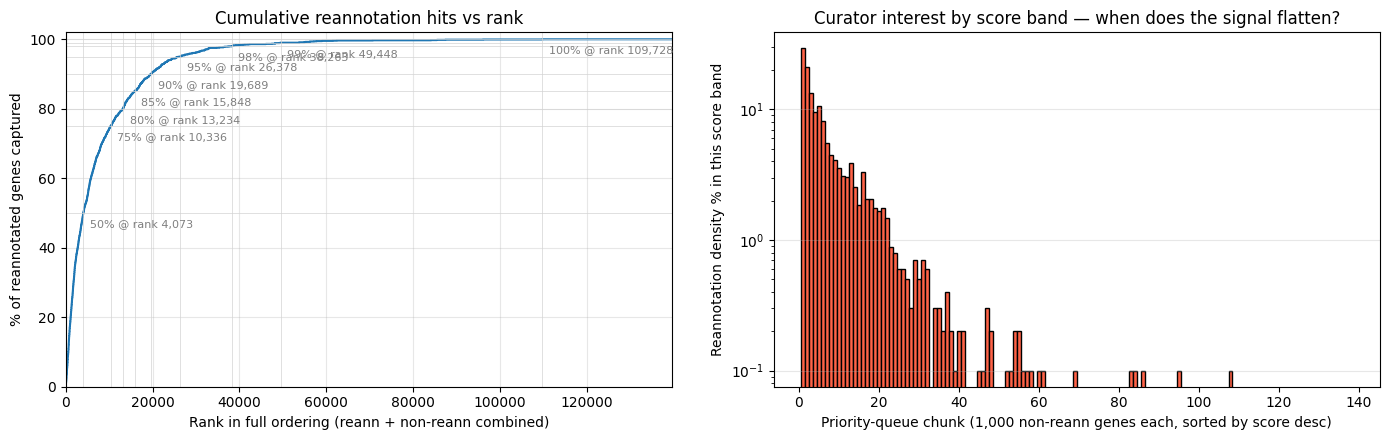

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Cumulative reann captured vs rank
ax = axes[0]
ax.plot(all_ranked.rank_all, all_ranked.cum_pct_reann, color="tab:blue", lw=1.5)
for p, r, _, _ in [tuple(row.values()) for row in ranks_at]:
    if r is None:
        continue
    ax.axhline(p, color="lightgray", lw=0.5)
    ax.axvline(r, color="lightgray", lw=0.5)
    ax.annotate(f"{int(p)}% @ rank {r:,}", xy=(r, p), xytext=(r + 1500, p - 4),
                fontsize=8, color="tab:gray")
ax.set_xlabel("Rank in full ordering (reann + non-reann combined)")
ax.set_ylabel("% of reannotated genes captured")
ax.set_title("Cumulative reannotation hits vs rank")
ax.set_xlim(0, len(all_ranked))
ax.set_ylim(0, 102)
ax.grid(alpha=0.3)

# (b) Reannotation density by chunk
ax = axes[1]
ax.bar(chunk_summary.chunk, chunk_summary.band_reann_density_pct,
       color="tomato", edgecolor="black", width=0.85)
ax.set_xlabel("Priority-queue chunk (1,000 non-reann genes each, sorted by score desc)")
ax.set_ylabel("Reannotation density % in this score band")
ax.set_title("Curator interest by score band — when does the signal flatten?")
ax.set_yscale("log")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
fig_path = FIG_DIR / "fig01_priority_queue.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved {fig_path}")
plt.show()

## 8. Reannotation rank distribution + annotation category by chunk

Saved /Users/paramvirdehal/KBase/ke-pangenome-science/projects/fitness_browser_stubborn_set/figures/fig02_rank_distribution.png


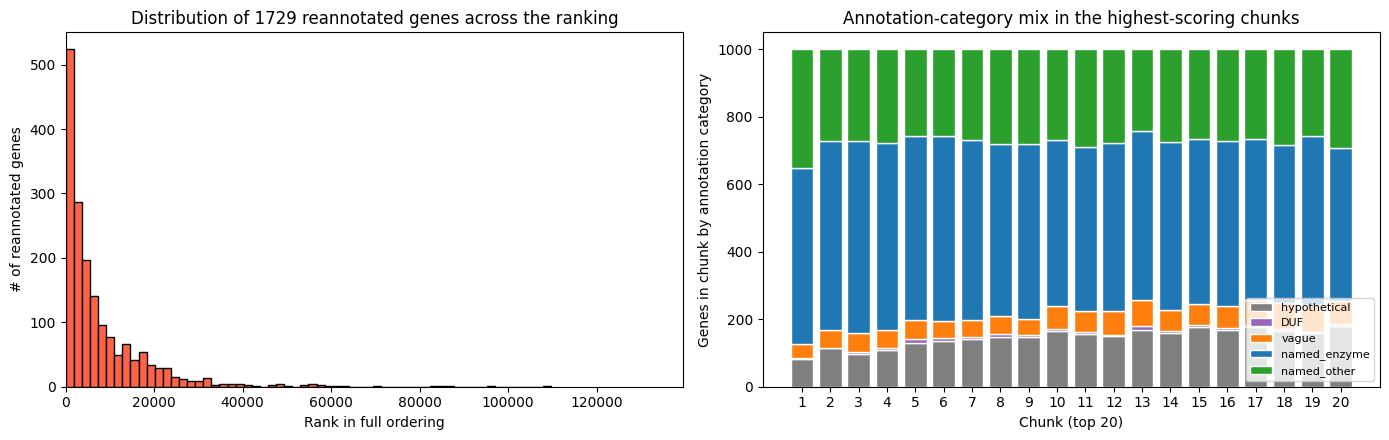

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Where do the 1,729 reannotated genes land in the ranking?
ax = axes[0]
reann_ranks = all_ranked.loc[all_ranked.is_reannotated == 1, "rank_all"].values
ax.hist(reann_ranks, bins=60, color="tomato", edgecolor="black")
ax.set_xlabel("Rank in full ordering")
ax.set_ylabel("# of reannotated genes")
ax.set_title(f"Distribution of {n_reann} reannotated genes across the ranking")
ax.set_xlim(0, len(all_ranked))

# (b) Annotation category mix by chunk (top 20 chunks)
ax = axes[1]
cats = ["hypothetical", "DUF", "vague", "named_enzyme", "named_other"]
top_chunks = chunk_summary.head(20)
bottom = np.zeros(len(top_chunks))
colors = {"hypothetical": "tab:gray", "DUF": "tab:purple", "vague": "tab:orange",
          "named_enzyme": "tab:blue", "named_other": "tab:green"}
for cat in cats:
    col = "n_" + cat
    vals = top_chunks[col].values
    ax.bar(top_chunks.chunk, vals, bottom=bottom, label=cat, color=colors[cat], edgecolor="white")
    bottom = bottom + vals
ax.set_xlabel("Chunk (top 20)")
ax.set_ylabel("Genes in chunk by annotation category")
ax.set_title("Annotation-category mix in the highest-scoring chunks")
ax.legend(fontsize=8, loc="lower right")
ax.set_xticks(top_chunks.chunk)

plt.tight_layout()
fig_path = FIG_DIR / "fig02_rank_distribution.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved {fig_path}")
plt.show()

## 9. Save artifacts

- `priority_queue.parquet` — the ranked non-reannotated list with all features,
  for NB02 to walk through.
- `chunk_summary.csv` — per-chunk diagnostics for stop-rule decisions.
- `reannotation_milestones.csv` — score thresholds at each cumulative-coverage milestone.

In [10]:
queue_out = DATA_DIR / "priority_queue.parquet"
chunk_out = DATA_DIR / "chunk_summary.csv"
milestone_out = DATA_DIR / "reannotation_milestones.csv"

queue.to_parquet(queue_out, index=False)
chunk_summary.to_csv(chunk_out, index=False)
milestones_df.to_csv(milestone_out, index=False)
print(f"Wrote {queue_out}  ({len(queue):,} rows)")
print(f"Wrote {chunk_out}  ({len(chunk_summary)} chunks)")
print(f"Wrote {milestone_out}")

Wrote /Users/paramvirdehal/KBase/ke-pangenome-science/projects/fitness_browser_stubborn_set/data/priority_queue.parquet  (137,798 rows)
Wrote /Users/paramvirdehal/KBase/ke-pangenome-science/projects/fitness_browser_stubborn_set/data/chunk_summary.csv  (138 chunks)
Wrote /Users/paramvirdehal/KBase/ke-pangenome-science/projects/fitness_browser_stubborn_set/data/reannotation_milestones.csv


## 10. Takeaways

- We reframed NB01's output from a binary stubborn-set to a **ranked priority
  queue** of non-reannotated genes ordered by curator-likeness score.
- The cumulative reannotation curve and per-chunk reannotation density tell
  NB02 where curator-like signal is rich vs sparse.
- NB02 will walk the queue in chunks of 1,000, computing secondary evidence
  (conserved cofitness, conserved specific phenotype via `specog`, informative
  domain/KEGG/SEED/MetaCyc) per chunk and stopping when the yield of
  improvable candidates plateaus.
- The 90% reannotation-coverage rank is the practical "stop reviewing past
  here" line — beyond that rank we're in territory most curators wouldn't
  have considered.